In [1]:
%load_ext autoreload
%autoreload 2

# Supervised spillover metrics

The `spillover_metrics_supervised` module provides metrics to assess how well the single cell profiles in the spatial transcriptomics dataset correlate with a reference scRNA-seq dataset. To compute these metrics, we load both datasets and transfer labels from the reference to the query dataset.

#### Load datasets

In [2]:
import anndata as ad
from pathlib import Path

# Load scRNA-seq dataset
scRNAseq_data_path = Path("/home/lazic/src/SegTraQ/tests/data/scRNAseq_ref.h5ad")
adata_ref = ad.read(scRNAseq_data_path)

/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/anndata/__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [3]:
import spatialdata as sd

st_data_path = Path("/home/lazic/src/SegTraQ/tests/data/xenium_sdata.zarr")
sdata_10x_xenium = sd.read_zarr(st_data_path)

/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
version mismatch: detected: RasterFormatV02, requested: FormatV04
/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_va

#### Transfer labels

In [4]:
import segtraq as sq

sq.run_label_transfer(sdata_10x_xenium,
                      adata_ref,
                      celltype_key="celltype_major",
                      inplace=True)

/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:138: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ref_mean_df = counts_df.groupby("celltype").mean()
/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:173: RuntimeWarning: Spatialdata table appears to contain raw counts. Counts will be log1p-transformed before running label transfer.
  warnings.

Transferred cell-type labels are saved in the AnnData object at `adata`.obs['transferred_celltype']` (one label per cell). The dominant cell type in the dataset is T cells with n=523.

In [5]:
sdata_10x_xenium.tables["table"].obs["transferred_celltype"].value_counts()

transferred_celltype
T            523
B            322
DCIS2        289
stromal      199
macro        151
DCIS1        150
endo         136
myoepi       131
dendritic     85
perivas       49
mast          25
tumor         12
Name: count, dtype: int64

Next, cell shapes can be plotted and colored by cell type based on a defined color palette. Some cells lack a transferred cell-type label (due to filtering low-count cells before label transfer); for compatibility with `spatialdata-plot`, we replace missing values (NaN) in `sdata_10x_xenium.tables["table].obs['transferred_celltype']` with `"Unknown"` before plotting.

In [6]:
import pandas as pd

# Replace NaN with Unknown
s = sdata_10x_xenium.tables["table"].obs["transferred_celltype"]  
if pd.api.types.is_categorical_dtype(s):
    s = s.cat.add_categories(["Unknown"])

sdata_10x_xenium.tables["table"].obs["transferred_celltype_plot"] = s.fillna("Unknown")

# Define color palette and groups for plotting
col_celltype = {
    "T": "#fb8072",
    "B": "#bc80bd",
    "macro": "#910290",
    "dendritic": "#fdb462",
    "mast": "#959059",
    "perivas": "#fed9a6",
    "endo": "#a6cee3",
    "myoepi": "#2782bb",
    "DCIS1": "#3c7761",
    "DCIS2": "#66a61e",
    "tumor": "#66c2a5",
    "stromal": "#d45943",
    "Unknown": "#808080"
}

labels = sdata_10x_xenium.tables["table"].obs["transferred_celltype_plot"].unique().astype(str).tolist()
cols = [col_celltype[l] for l in labels]

/tmp/ipykernel_279526/1634191233.py:5: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(s):


/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `cell_boundaries` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/spatialdata/_core/_elements.py

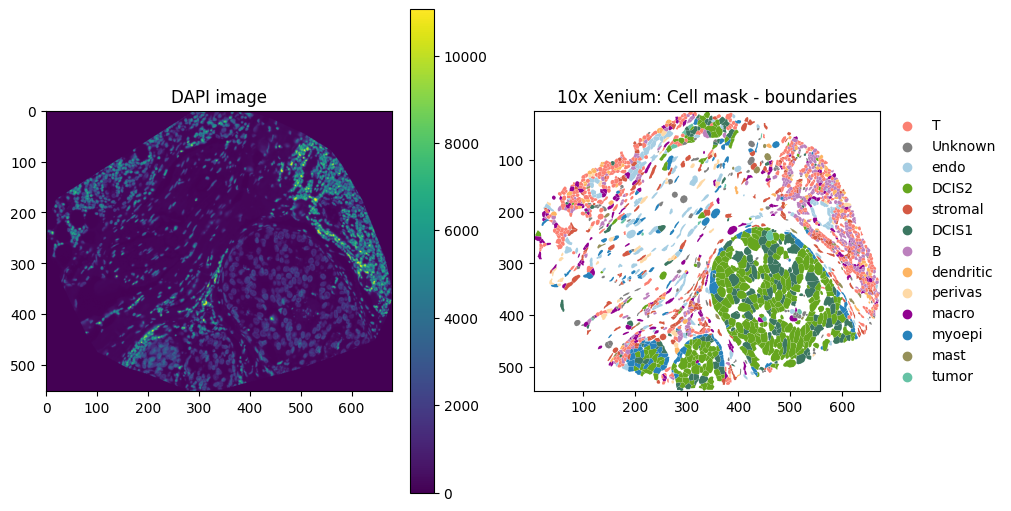

In [7]:
import matplotlib.pyplot as plt
import spatialdata_plot

axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

#Dapi image
sdata_10x_xenium.pl.render_images("morphology_focus").pl.show(
    ax=axes[0], title="DAPI image", coordinate_systems="global"
)

# Plot - Cell boundaries
sdata_10x_xenium.tables["table"].obs["region"] = "cell_boundaries"
sdata_10x_xenium.set_table_annotates_spatialelement("table", region="cell_boundaries")

sdata_10x_xenium.pl.render_shapes("cell_boundaries", 
                                  color="transferred_celltype_plot", 
                                  palette=cols,
                                  groups=labels).pl.show(
    ax=axes[1], title="10x Xenium: Cell mask - boundaries", coordinate_systems="global"
)

In [8]:
import scanpy as sc

tbl = sdata_10x_xenium.tables["table"]

sc.pp.normalize_total(tbl, target_sum=1e4)
sc.pp.log1p(tbl)

/home/lazic/miniforge3/envs/segtraq/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


#### Compute positive and negative markers

Positive and negative markers per cell type are identified by computing, for each gene, the difference between its mean expression within the target cell type and its mean expression across all other cells, then selecting genes above the `q_pos` quantile as positive markers and below the `q_neg` quantile as negative markers. To enforce type specificity, genes that appear in at least a `t · n_celltypes` fraction of the per-type marker lists are removed separately for positives and negatives.

We will only consider genes common to the scRNA-seq and spatial transcriptomics dataset to reduce compute time.

In [9]:
common_genes = tbl.var_names[tbl.var_names.isin(adata_ref.var_names)]
adata_ref = adata_ref[:, common_genes].copy()

In [10]:
markers = sq.sp.get_ref_markers(adata_ref, 
                      cell_type_column="celltype_major",
                      q_pos=0.95,
                      q_neg=0.1,
                      t=0.25)

The first 20 positive markers in B cells include B-lineage signaling genes (BANK1, BLK, BLNK), supporting gens (BACH2, BCL11A, BCL2), genes upregulated downstream of BCR signaling (APOBEC3C/D/F) and ADAM28 reported in B-cell populations.

In [11]:
markers['B']['positive'][:20]

['ACP5',
 'ADAM28',
 'ADAM8',
 'ADGRG5',
 'AIM2',
 'AKAP11',
 'AMFR',
 'ANGPTL6',
 'ANKHD1',
 'ANKRD13A',
 'APOBEC3C',
 'APOBEC3D',
 'APOBEC3F',
 'ATP2B1',
 'BACH2',
 'BANK1',
 'BCL11A',
 'BCL2',
 'BLK',
 'BLNK']

Among T cell positive markers, we find well-known T cell lienage markers and co-stimulatory receptors.

In [12]:
markers['T']['positive'][25:30]

['CD27', 'CD28', 'CD3D', 'CD3E', 'CD3G']

#### Find mutually exclusive marker pairs

Mutually exclusive gene pairs are identified by scanning each cell type’s positive markers, keeping genes expressed in >20% of that type but <5% of all other cells and retaining only genes that satisfy this criterion for a single type. It then returns all cross-type combinations of these type-unique genes as (gene1, gene2) pairs.

In [13]:
mut_excl_marker_pairs = sq.sp.get_mut_excl_markers(adata_ref,
                                                   cell_type_column="celltype_major",
                                                   markers=markers,
                                                   pos_threshold=0.2,
                                                   neg_threshold=0.05,
                                                   max_codetect=0.01)

In [14]:
mut_excl_marker_pairs[10:20]

[('CD22', 'TCL1A'),
 ('CD22', 'TLR9'),
 ('CD79A', 'SHD'),
 ('CD79A', 'TCL1A'),
 ('CD79A', 'TLR9'),
 ('CD79B', 'SHD'),
 ('CD79B', 'TCL1A'),
 ('CD79B', 'TLR9'),
 ('FCRL1', 'SHD'),
 ('FCRL1', 'TCL1A')]

The mutually exclusive co-expression Rate (`MECR`) per gene pair in the spatial transcriptomics dataset can be calculated using `compute_MECR`. MECR (Mutually Exclusive Co-expression Rate) measures how often two genes are co-detected relative to how often either is detected, i.e. `MECR = P(both>0) / P(g1>0 ∪ g2>0)`. The median MECR is zero, however 16% of the gene pairs found to be mutually excluisve in the reference scRNA-seq dataset have non-zero MECR with a median of 0.026.

In [15]:
mecr = sq.sp.compute_MECR(sdata_10x_xenium,
                    gene_pairs=mut_excl_marker_pairs)

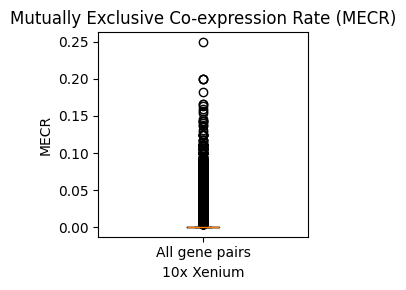

In [16]:
vals = list(mecr.values())

fig, ax = plt.subplots(figsize=(3, 3))
ax.boxplot([vals], vert=True)
ax.set_title("Mutually Exclusive Co-expression Rate (MECR)")
ax.set_xlabel("10x Xenium")
ax.set_ylabel("MECR")
ax.set_xticklabels(["All gene pairs"])
plt.tight_layout()
plt.show()


In [17]:
import numpy as np
vals_nz = [x for x in vals if x > 0] #non zero
print(f"Median MECR = {np.median(vals_nz)} and variance = {np.var(vals_nz)}")

Median MECR = 0.02631578947368421 and variance = 0.0004343371472423579


In [18]:
len(vals_nz)/len(vals)

0.16462793068297654

#### Evaluate positive and negative marker purity

Positive and negative marker purity in the spatial transcriptomics datasets can be computed via `calculate_marker_purity`. It evaluates, for each cell, how well its expected positive markers are among the cell’s top-expressed genes and how well the negative markers are not among those top genes, using a quantile/rank threshold based on the size of each marker list. From this it computes precision, recall, and F1 for both marker sets and combines them into a single “purity” score that rewards strong positive signal and penalizes negative signal. The output is a per-cell table of these metrics alongside the annotated cell type.

In [19]:
purity_df = sq.sp.calculate_marker_purity(sdata_10x_xenium,
                              celltype_column="transferred_celltype",
                              markers=markers)

In [20]:
purity_df

,positive_precision,positive_recall,positive_F1,negative_precision,negative_recall,negative_F1,F1_purity
cell_id,,,,,,,
bfdldgcn-1,0.127273,0.040698,0.061674,0.054545,0.005894,0.010638,0.116110
bfdlebgn-1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
bfdlfpan-1,0.166667,0.005780,0.011173,0.000000,0.000000,0.000000,0.022099
bfdlgpib-1,0.148148,0.023256,0.040201,0.185185,0.009823,0.018657,0.077238
bfdljaab-1,0.269231,0.040698,0.070707,0.153846,0.007859,0.014953,0.131943
...,...,...,...,...,...,...,...
oildcggb-1,0.300000,0.017751,0.033520,0.000000,0.000000,0.000000,0.064865
oilfednk-1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
oilfeima-1,0.111111,0.005348,0.010204,0.000000,0.000000,0.000000,0.020202


In [21]:
# add purity scores to AnnData observations

tbl.obs = tbl.obs.merge(
    purity_df.reset_index(),
    how="left",
    left_on="cell_id",  
    right_on="cell_id", 
)

Cell type "tumor" yields the lowest purity F1 score and DCIS2 the highest. 

/tmp/ipykernel_279526/4220303417.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = df.groupby('transferred_celltype_plot')['F1_purity'].median().sort_values(ascending=False).index


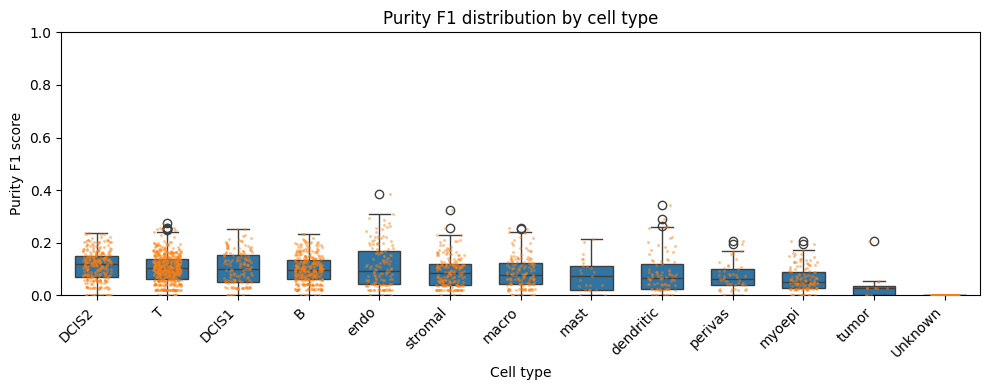

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

df = tbl.obs[['transferred_celltype_plot', 'F1_purity']].dropna()

order = df.groupby('transferred_celltype_plot')['F1_purity'].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='transferred_celltype_plot', y='F1_purity', order=order, width=0.6)
sns.stripplot(data=df, x='transferred_celltype_plot', y='F1_purity', order=order, alpha=0.5, size=2, jitter=0.2)

plt.ylim(0, 1)  
plt.xlabel('Cell type')
plt.ylabel('Purity F1 score')
plt.title('Purity F1 distribution by cell type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [23]:
df.groupby('transferred_celltype_plot')['F1_purity'].median()

/tmp/ipykernel_279526/767544993.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('transferred_celltype_plot')['F1_purity'].median()


transferred_celltype_plot
B            0.096837
DCIS1        0.100519
DCIS2        0.117397
T            0.103236
dendritic    0.067454
endo         0.094098
macro        0.078040
mast         0.072687
myoepi       0.048780
perivas      0.063150
stromal      0.083256
tumor        0.028682
Unknown      0.000000
Name: F1_purity, dtype: float64

#### Neigbhorhood contamination

Use `calculate_contamination` to quantify directional “leakage” between cell types in spatial data: for each `ct` cell, it uses a Squidpy spatial neighbors graph to measure what share of ct-specific positive-marker signal appears inside neighboring `ct2` cells, then averages these fractions into a ct→ct2 matrix. 

Higher entries suggest spillover rather than true biology.

In [24]:
cont_df_diag, cont_df = sq.sp.calculate_contamination(sdata_10x_xenium, 
                              markers=markers,
                              celltype_column="transferred_celltype",
                              cell_centroid_x_key="x_centroid",
                              cell_centroid_y_key="y_centroid"
                              )

It is not good to look at this in a boxplot because dominant neighbors will dominate the results. DCIS2 incoming signal will mostly be dominated by DCIS1 outgoing signal and since there is a lot of DCIS1 ...better to look at heatmap where this is scaled by the number of interactions.

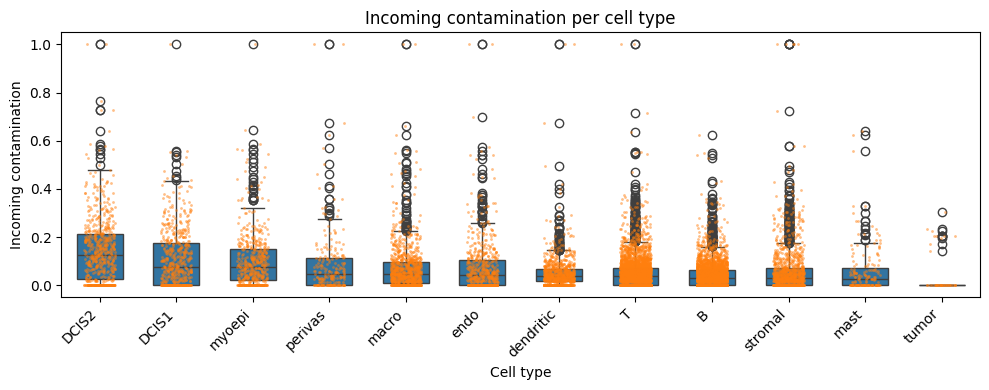

In [25]:
cont_df = cont_df[['neighbor_type', 'ratio']].dropna()

order = cont_df.groupby('neighbor_type')['ratio'].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 4))
sns.boxplot(data=cont_df, x='neighbor_type', y='ratio', order=order, width=0.6)
sns.stripplot(data=cont_df, x='neighbor_type', y='ratio', order=order, alpha=0.5, size=2, jitter=0.2)

#plt.ylim(0, 12)  
plt.xlabel('Cell type')
plt.ylabel('Incoming contamination')
plt.title('Incoming contamination per cell type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_279526/4019968585.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = cont_df.groupby('transferred_celltype_plot')['transcript_count'].median().sort_values(ascending=False).index


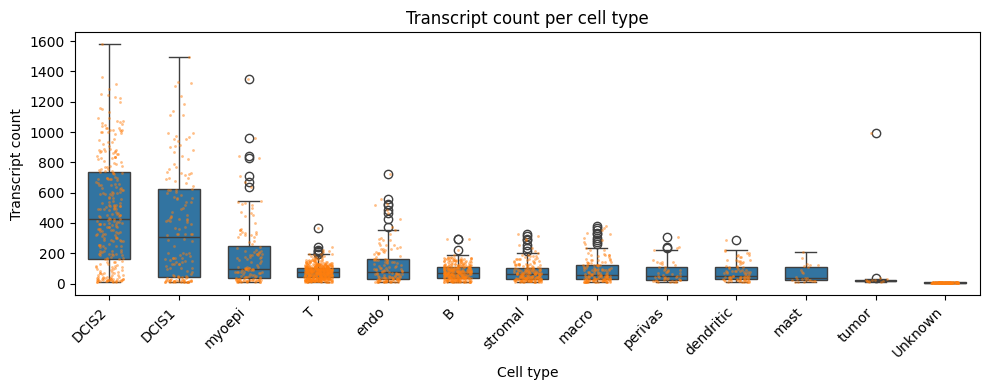

In [29]:
cont_df = tbl.obs[['transferred_celltype_plot', 'transcript_count']].dropna()

order = cont_df.groupby('transferred_celltype_plot')['transcript_count'].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 4))
sns.boxplot(data=cont_df, x='transferred_celltype_plot', y='transcript_count', order=order, width=0.6)
sns.stripplot(data=cont_df, x='transferred_celltype_plot', y='transcript_count', order=order, alpha=0.5, size=2, jitter=0.2)

#plt.ylim(0, 12)  
plt.xlabel('Cell type')
plt.ylabel('Transcript count')
plt.title('Transcript count per cell type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

I am not 100% sure how to interpret the heatmap below...

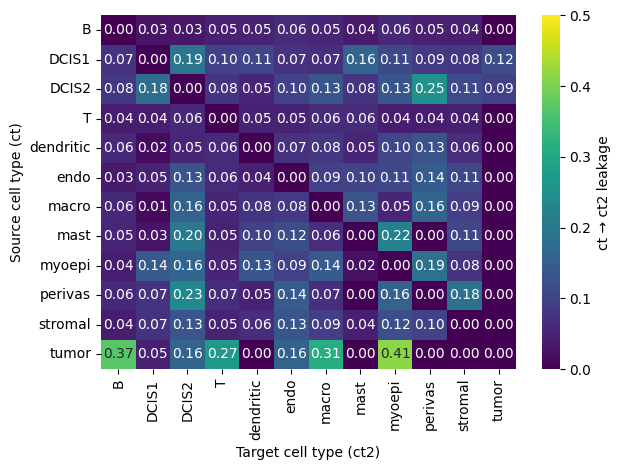

In [33]:
ax = sns.heatmap(cont_df_diag, vmin=0, vmax=0.5, cmap="viridis", annot=True, fmt=".2f",
                 cbar_kws={"label": "ct → ct2 leakage"})
ax.set_xlabel("Target cell type (ct2)")
ax.set_ylabel("Source cell type (ct)")
plt.tight_layout()

Contamination and purity for individual cell types do not seem to correlate. Strong correlation between purity and contamination isn’t guaranteed, since the two readouts measure different things:

Purity is an intracellular score (does each cell’s own profile match its marker set?).

Contamination is a directional, neighborhood metric (what fraction of a type-specific signature from cells of type ct shows up in nearby ct2 cells). Because it depends on spatial adjacency and a graph, it can vary independently of per-cell purity.

A cell (e.g. of type DCIS1) can have a pure expression, but still have a high contamination of neighboring cell positive markers with respect to the expression of those markers in this respective neighborhood. 

In [33]:
tbl.X.toarray().ravel(axis=1)

TypeError: ravel() got an unexpected keyword argument 'axis'